In [1]:
# ---
# Setup & Initialization
# ---
import os
import random
import time
import gc
import sys
from pathlib import Path

import torch
import torchaudio
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure src/ is in the python path
for _candidate in [Path().resolve().parent / 'src', Path().resolve() / 'src']:
    if _candidate.exists() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        break

from encodec import EncodecModel
from encodec.utils import convert_audio

# Define Global Target Species
TARGET_SPECIES = "Thyolo"
PROJECT_ROOT = Path().resolve().parent
AUDIO_DIR = PROJECT_ROOT / "Data" / TARGET_SPECIES / "Audio"
OUTPUT_DIR = PROJECT_ROOT / "Data" / TARGET_SPECIES / "Compression_Analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# ---
# Select a Random Audio File
# ---
audio_files = [f for f in AUDIO_DIR.iterdir() if f.suffix.lower() == '.wav']
if not audio_files:
    raise FileNotFoundError(f"No WAV files found in {AUDIO_DIR}")

selected_file = random.choice(audio_files)
print(f"Selected file: {selected_file.name}")

# Load the file
wav, sr = torchaudio.load(selected_file)

# NOTE: Bioacoustic files in this dataset are ~30 mins long (110MB).
# Running 5 encodec models on CPU sequentially for 30 mins of audio will take hours.
# Processing the full file (110MB) takes a long time. Set CROP_SECONDS = 30 to run a quick test on 30 seconds.
# To process the full file, set CROP_SECONDS = None
CROP_SECONDS = None  # Changed to None to process the full 114.9MB file. WARNING: This will take a long time on CPU! 

if CROP_SECONDS is not None:
    max_samples = int(CROP_SECONDS * sr)
    if wav.shape[1] > max_samples:
        wav = wav[:, :max_samples]

wav_cpu = wav.to('cpu')

# Calculate original size of this specific audio tensor in bytes
# (We use the raw byte size of the tensor data, matching standard uncompressed PCM)
original_size_bytes = selected_file.stat().st_size  # Exact size of the .WAV file on disk

print(f"Processing audio of duration: {wav.shape[1]/sr:.2f} seconds")
print(f"Original Audio Raw Size: {original_size_bytes / 1024 / 1024:.2f} MB")


Selected file: 20201130_180000.WAV


/home/milanto/.local/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/home/milanto/.local/lib/python3.9/site-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more informa

Processing audio of duration: 1795.00 seconds
Original Audio Raw Size: 109.56 MB


In [3]:
# ---
# Utility: SI-SNR Calculation
# ---
def si_snr(target, estimate, eps=1e-8):
    """
    Calculate Scale-Invariant Signal-to-Noise Ratio (SI-SNR).
    Higher is better.
    """
    target = target - target.mean()
    estimate = estimate - estimate.mean()
    
    alpha = (torch.sum(estimate * target) + eps) / (torch.sum(target ** 2) + eps)
    target_scaled = alpha * target
    noise = estimate - target_scaled
    
    val = 10 * torch.log10((torch.sum(target_scaled ** 2) + eps) / (torch.sum(noise ** 2) + eps))
    return val.item()


In [4]:
# ---
# Compression & Reconstruction Loop
# ---
bitrates = [1.5, 3.0, 6.0, 12.0, 24.0]
results = []

for bw in bitrates:
    print(f"\n--- Processing Bitrate: {bw} kbps ---")
    
    # 1. Initialize Model
    model = EncodecModel.encodec_model_24khz()
    model.set_target_bandwidth(bw)
    model.to('cpu')
    
    # 2. Resample to EnCodec's expected sample rate (24kHz)
    wav_resampled = convert_audio(wav_cpu, sr, model.sample_rate, model.channels)
    wav_in = wav_resampled.unsqueeze(0) # [1, channels, time]
    
    # 3. Chunking logic (Memory Management)
    chunk_length_sec = 1.0
    overlap_sec = 0.010
    chunk_length = int(chunk_length_sec * model.sample_rate)
    overlap = int(overlap_sec * model.sample_rate)
    step = chunk_length - overlap
    
    total_length = wav_in.shape[-1]
    reconstructed_wav = torch.zeros_like(wav_in)
    overlap_add_weights = torch.zeros_like(wav_in)
    window = torch.hann_window(chunk_length).to('cpu')
    
    all_codes = []
    
    start_time = time.time()
    
    # 4. Processing Chunks
    with torch.no_grad():
        for start in range(0, total_length, step):
            end = min(start + chunk_length, total_length)
            current_chunk_length = end - start
            chunk = wav_in[:, :, start:end]
            
            # Pad if last chunk
            pad_length = chunk_length - current_chunk_length
            if pad_length > 0:
                chunk = torch.nn.functional.pad(chunk, (0, pad_length))
                
            # Encode (Compress)
            encoded_frames = model.encode(chunk)
            # Save the compressed latent codes
            all_codes.append(encoded_frames[0][0].cpu().clone())
            
            # Decode (Reconstruct)
            # Handle different versions of encodec API gracefully
            if hasattr(model, 'decompress'):
                decoded_chunk = model.decompress(encoded_frames)
            else:
                decoded_chunk = model.decode(encoded_frames)
                
            decoded_chunk = decoded_chunk * window
            
            # Overlap-Add
            reconstructed_wav[:, :, start:end] += decoded_chunk[:, :, :current_chunk_length]
            overlap_add_weights[:, :, start:end] += window[:current_chunk_length]
            
            del chunk, encoded_frames, decoded_chunk
            
    # 5. Normalize overlapping regions
    nonzero_idx = overlap_add_weights > 1e-12
    reconstructed_wav[nonzero_idx] /= overlap_add_weights[nonzero_idx]
    reconstructed_wav[~nonzero_idx] = 0.0
    
    exec_time = time.time() - start_time
    
    # 6. Save Outputs
    # Save the compressed bitstream (PyTorch Tensor of latents)
    bitstream_file = OUTPUT_DIR / f"{selected_file.stem}_compressed_{bw}kbps.pt"
    torch.save(all_codes, bitstream_file)
    
    # Save the reconstructed .wav file
    reconstructed_file = OUTPUT_DIR / f"{selected_file.stem}_reconstructed_{bw}kbps.wav"
    torchaudio.save(reconstructed_file, reconstructed_wav.squeeze(0), model.sample_rate)
    
    # 7. Collect Metrics
    compressed_size_bytes = bitstream_file.stat().st_size
    snr_val = si_snr(wav_resampled.squeeze(), reconstructed_wav.squeeze())
    
    results.append({
        'Bitrate (kbps)': bw,
        'Original Size (MB)': original_size_bytes / (1024*1024),
        'Compressed Size (MB)': compressed_size_bytes / (1024*1024),
        'Compression Ratio': original_size_bytes / compressed_size_bytes,
        'SI-SNR (dB)': snr_val,
        'Processing Time (s)': exec_time
    })
    
    # Cleanup memory
    del model, wav_resampled, wav_in, reconstructed_wav, overlap_add_weights, window, all_codes
    gc.collect()

print("\nProcessing Complete!")



--- Processing Bitrate: 1.5 kbps ---


/home/milanto/.local/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/home/milanto/.local/lib/python3.9/site-packages/torchaudio/_backend/utils.py:337: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.save_with_torchcodec` under the hood. Some parameters like format, encoding, bits_per_sample, buffer_size, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's encoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.encoders.AudioEncoder
  warnings.warn(
/home/milanto/.local/lib/python3.9/site-packages/torchaudio/_backend/ffmpeg.py:247: UserWarning: torio.io._streaming_media_encoder.StreamingMediaEncoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a m


--- Processing Bitrate: 3.0 kbps ---


/home/milanto/.local/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



--- Processing Bitrate: 6.0 kbps ---

--- Processing Bitrate: 12.0 kbps ---

--- Processing Bitrate: 24.0 kbps ---

Processing Complete!


,Bitrate (kbps),Original Size (MB),Compressed Size (MB),Compression Ratio,SI-SNR (dB),Processing Time (s)
0,1.5,109.558571,2.619618,41.822340,-25.300180,220.014279
1,3.0,109.558571,4.614247,23.743541,-16.888086,233.559420
2,6.0,109.558571,8.821523,12.419463,-11.730901,204.691183
3,12.0,109.558571,17.127091,6.396800,-9.027082,221.466169
4,24.0,109.558571,33.734757,3.247647,-8.346230,222.588372


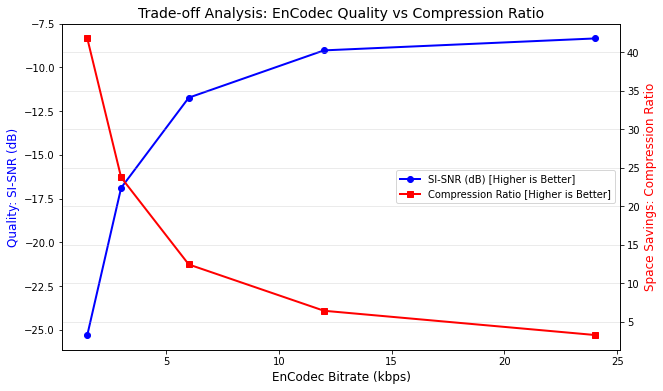

In [5]:
# ---
# Analysis & Comparison Data
# ---
df = pd.DataFrame(results)
display(df)

# Plot: Compression Ratio vs SI-SNR
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

line1 = ax1.plot(df['Bitrate (kbps)'], df['SI-SNR (dB)'], 'b-o', label='SI-SNR (dB) [Higher is Better]', linewidth=2)
line2 = ax2.plot(df['Bitrate (kbps)'], df['Compression Ratio'], 'r-s', label='Compression Ratio [Higher is Better]', linewidth=2)

ax1.set_xlabel('EnCodec Bitrate (kbps)', fontsize=12)
ax1.set_ylabel('Quality: SI-SNR (dB)', color='b', fontsize=12)
ax2.set_ylabel('Space Savings: Compression Ratio', color='r', fontsize=12)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

plt.title('Trade-off Analysis: EnCodec Quality vs Compression Ratio', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()


/home/milanto/.local/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/home/milanto/.local/lib/python3.9/site-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more informa

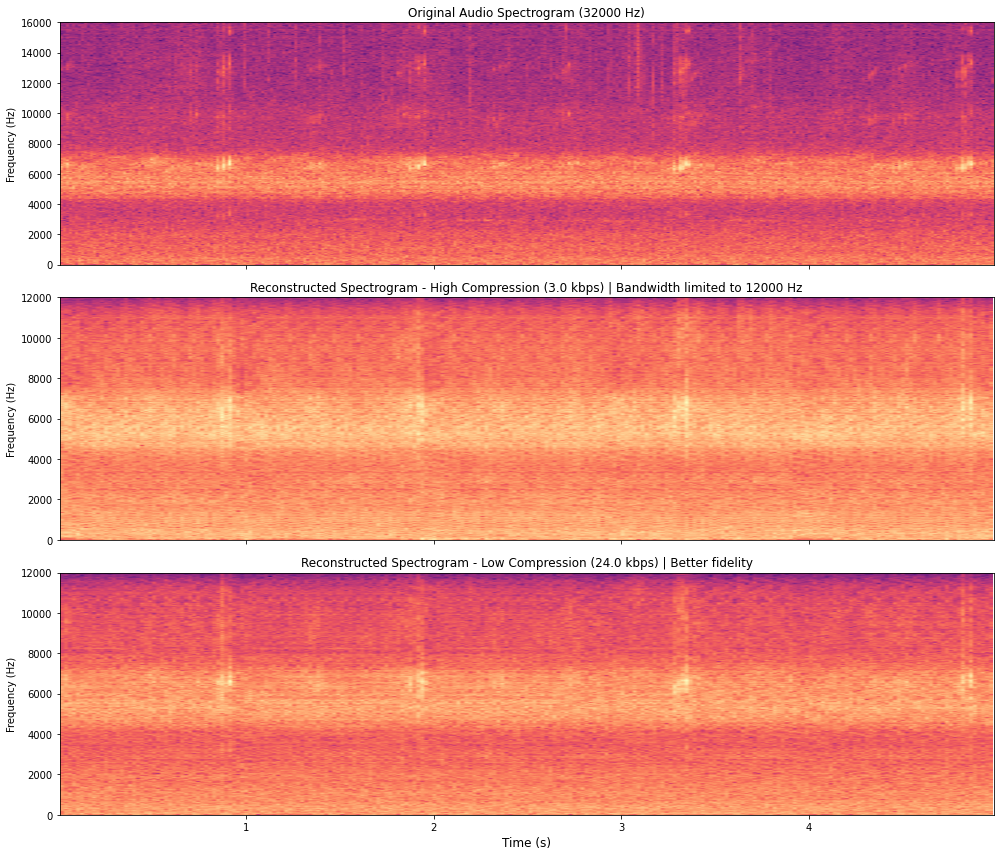

In [6]:
# ---
# Visual Spectrogram Comparison
# ---
# Load original and specific reconstructions to visually compare feature loss
file_3_0 = OUTPUT_DIR / f"{selected_file.stem}_reconstructed_3.0kbps.wav"
file_24_0 = OUTPUT_DIR / f"{selected_file.stem}_reconstructed_24.0kbps.wav"

wav_orig, orig_sr = torchaudio.load(selected_file)
wav_3_0, recon_sr = torchaudio.load(file_3_0)
wav_24_0, _ = torchaudio.load(file_24_0)

# We view a small 5-second slice so bioacoustic features (bird calls, bugs) are highly visible
view_start_sec = 5
view_end_sec = 10

# Ensure indices are within bounds
orig_start = int(view_start_sec * orig_sr)
orig_end = min(int(view_end_sec * orig_sr), wav_orig.shape[1])
recon_start = int(view_start_sec * recon_sr)
recon_end = min(int(view_end_sec * recon_sr), wav_3_0.shape[1])

slice_orig = wav_orig[0, orig_start:orig_end].numpy()
slice_3_0 = wav_3_0[0, recon_start:recon_end].numpy()
slice_24_0 = wav_24_0[0, recon_start:recon_end].numpy()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True, sharey=False)

# 1. Original
Pxx, freqs, bins, im = axes[0].specgram(slice_orig, Fs=orig_sr, NFFT=1024, noverlap=512, cmap='magma')
axes[0].set_title(f'Original Audio Spectrogram ({orig_sr} Hz)', fontsize=12)
axes[0].set_ylabel('Frequency (Hz)')

# 2. Reconstructed (3.0 kbps)
axes[1].specgram(slice_3_0, Fs=recon_sr, NFFT=1024, noverlap=512, cmap='magma')
axes[1].set_title(f'Reconstructed Spectrogram - High Compression (3.0 kbps) | Bandwidth limited to {recon_sr//2} Hz', fontsize=12)
axes[1].set_ylabel('Frequency (Hz)')

# 3. Reconstructed (24.0 kbps)
axes[2].specgram(slice_24_0, Fs=recon_sr, NFFT=1024, noverlap=512, cmap='magma')
axes[2].set_title(f'Reconstructed Spectrogram - Low Compression (24.0 kbps) | Better fidelity', fontsize=12)
axes[2].set_xlabel('Time (s)', fontsize=12)
axes[2].set_ylabel('Frequency (Hz)')

plt.tight_layout()
plt.show()
